# Lab 3
### Averaging Filters

http://scikit-image.org/docs/0.13.x/api/skimage.util.html#skimage.util.random_noise

http://scikit-image.org/docs/dev/api/skimage.filters.html#skimage.filters.median

http://scikit-image.org/docs/dev/api/skimage.filters.html#skimage.filters.gaussian

In [1]:
from commonfunctions import *
import math
import skimage.io as io
import matplotlib.pyplot as plt
import numpy as np
from skimage.color import rgb2gray
from scipy import fftpack
from scipy.signal import convolve2d
from skimage.util import random_noise
from skimage.exposure import rescale_intensity
from skimage.filters import median, gaussian

%matplotlib inline
%load_ext autoreload
%autoreload 2

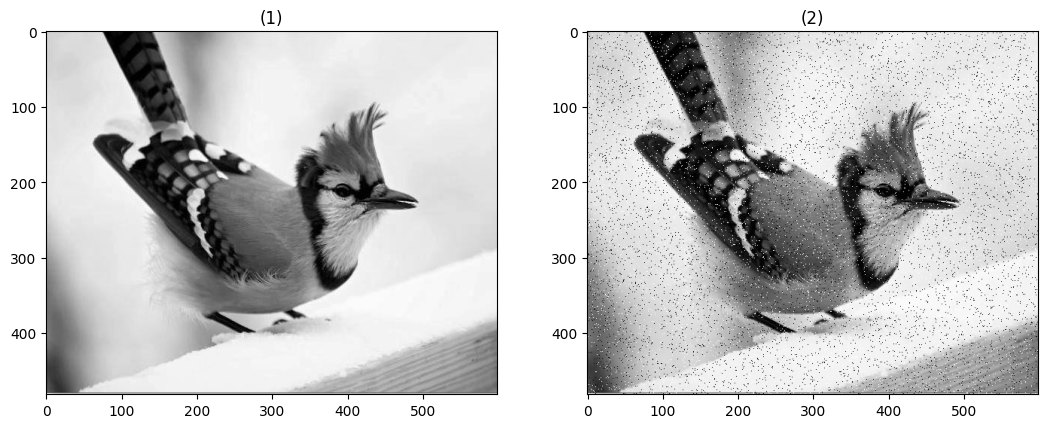

[[101 206 208 ... 236 234 231]
 [101 207 208 ... 237 235 233]
 [102 207 208 ... 238 237 235]
 ...
 [101  87  85 ... 131 129 127]
 [100 101 100 ...  98  99  99]
 [245 245 245 ... 198 198 199]]


In [2]:
# 1a
img = rgb2gray(io.imread("imgs/bird.jpg"))
img *= 255
img = img.astype(np.uint8)

#1b
noisy_img = random_noise(img, mode='s&p', amount=0.05)

show_images([img, noisy_img])

print(img)

In [3]:
'''
(1) Your own median filter algorithm
'''
# 1c
def median_filter(img):
    for rowidx, row in enumerate(img):
        if rowidx == 0 or rowidx == len(img)-1:
            continue
        for i in range(1, len(row) - 1):
            neighbors = np.array([])
            neighbors = np.append(neighbors, img[rowidx, i])
            neighbors = np.append(neighbors, img[rowidx - 1, i - 1])
            neighbors = np.append(neighbors, img[rowidx - 1, i + 1])
            neighbors = np.append(neighbors, img[rowidx + 1, i - 1])
            neighbors = np.append(neighbors, img[rowidx + 1, i + 1])
            neighbors = np.append(neighbors, img[rowidx, i - 1])
            neighbors = np.append(neighbors, img[rowidx - 1, i])
            neighbors = np.append(neighbors, img[rowidx + 1, i])
            neighbors = np.append(neighbors, img[rowidx, i + 1])
            neighbors = sorted(neighbors)
            med = neighbors[len(neighbors)//2]
            img[rowidx, i] = med
    return img
        


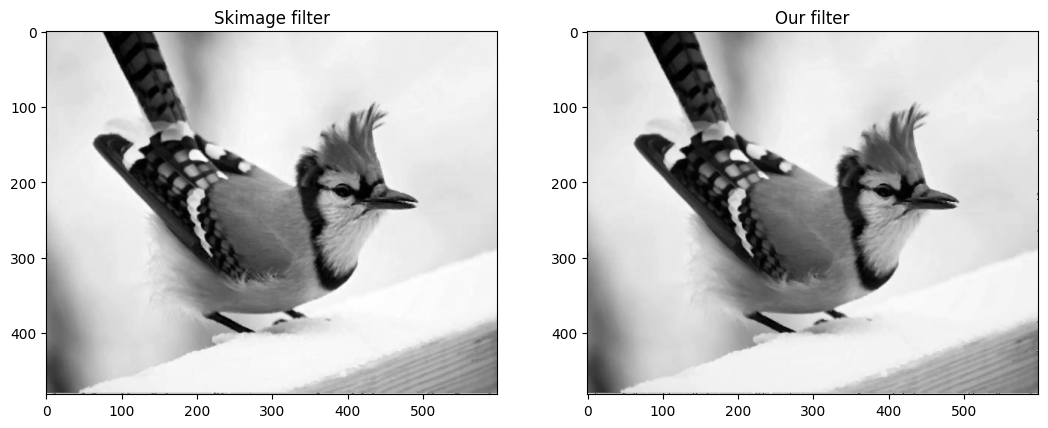

In [4]:
'''
(2) skimage median filter
'''

new_img1 = median(noisy_img, footprint=np.ones((3,3)))
new_img2 = median_filter(noisy_img)

# 1d
show_images([new_img1, new_img2], titles=["Skimage filter", "Our filter"])

#Note: the 2 imgs only differ on the boundaries since our function skips them but the skimage function handles boundaries differently


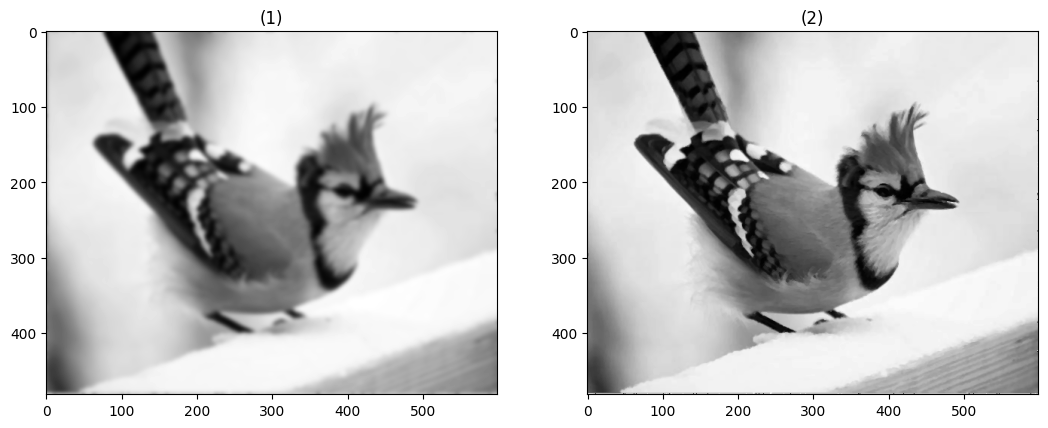

In [5]:
'''
(3) Gaussion Filters
'''

less_noise = gaussian(noisy_img, 2.5)
high_contrast = gaussian(noisy_img, 0.3)



show_images([less_noise, high_contrast])